# Egypt spare parts prices: the numbers

Every number in the README and in the header picture comes from this notebook: the last cell writes
them to `analysis/numbers.json` and into the README and `docs/*.svg`. It reads the gold star of the
warehouse after a weekly run (start the stack with `docker compose up -d`), then runs top to bottom.
Silver is read only where gold does not carry the fact: the rows set aside by the check, and the brand
of each offer. Bronze is read only for the pages, for each site's own count of its products, and for
the fetch times.

The rules for every measure below:

- **The latest run week only.** Each offer is counted once, at its price in the latest run week.
- **The comparable price of a seller** for one of our parts is its cheapest listing of that part
  that is comparable (within 3 times of the group's median, either way) and not shown out of stock:
  the rule of the `gold.price_gap` view. Out-of-stock and far-off prices are left out.
- **A group** is one of our parts: the offers matched to it. A group is measured only when it has
  at least 3 comparable offers not shown out of stock from at least 2 sellers; smaller groups are
  skipped and counted.
- **Medians, not means,** and every median is printed with its n.
- **Part number and part type are kept apart** where it matters: `part_number` groups share one
  part code; `type_model` groups share a part type and a car model, so they mix brands.
- **Our price is made up:** the median of the group's comparable offers. "A seller at least 5% below
  our price" means at least 5% below the market's middle price.
- Nothing here says why a price is what it is: these are descriptions, not causes.

`car_key` in `config/client.yaml` (say `hyundai` or `hyundai-elantra`; the environment variable `CAR_KEY`,
when set, wins) limits every number to one car: an offer by the car its title names, a part by the car it fits. Pages, rows set aside, the
sites' own counts and the fetch times belong to the whole run and do not change with it.

In [1]:
import gzip
import json
import os
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import psycopg
from dotenv import load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
sys.path.insert(0, str(ROOT))
from config import load_config  # noqa: E402

CAR_KEY = load_config()["car_key"]  # None = all cars; when set, every number is for car_key LIKE CAR_KEY || '%'

load_dotenv(ROOT / ".env")  # WAREHOUSE_PASSWORD, as the DAG reads it
conn = psycopg.connect(host=os.environ.get("WAREHOUSE_HOST", "localhost"), port=os.environ.get("WAREHOUSE_PORT", "5450"),
                       dbname="parts", user="parts", password=os.environ["WAREHOUSE_PASSWORD"])
MIN_OFFERS, MIN_SELLERS = 3, 2  # a group is measured from 3 comparable offers at 2 sellers
MIN_GROUPS = 5                  # a family, a seller or a brand split is shown from 5 groups
N = {"car_key": CAR_KEY}        # every number, written to analysis/numbers.json by the last cell


def query(sql, *params):
    with conn.cursor() as cur:
        cur.execute(sql, params)
        return pd.DataFrame(cur.fetchall(), columns=[c.name for c in cur.description])


def for_car(df, column):
    """The rows whose car starts with CAR_KEY (all rows when CAR_KEY is not set)."""
    return df if CAR_KEY is None else df[df[column].fillna("").str.startswith(CAR_KEY)]


def pct(part, whole):
    return 100 * part / whole if whole else None


ACCENT, GREY, INK, LINE = "#2563EB", "#4A5675", "#0E1630", "#E2E7F1"  # the sibling tracker's report colours
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": LINE,
                     "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
                     "figure.dpi": 110, "savefig.bbox": "tight"})

## 1. What one weekly run reads

Every offer in the latest run week from the gold fact, with its seller, part and match grade. The
offer counts and the sellers follow `CAR_KEY` by the offer's own car; the matched offers by the car of
the part they are matched to.

In [2]:
everything = query("""
    SELECT s.seller_id, s.name AS seller, f.listing_key, f.part_key, p.part_no, p.name AS part_name, p.family,
           p.is_key, p.car_key AS part_car_key, f.match_grade, f.comparable, f.price, f.in_stock, f.is_discounted,
           f.part_type, f.car_key, d.run_week
    FROM gold.fact_price_observation f
    JOIN gold.dim_seller s USING (seller_key) JOIN gold.dim_part p USING (part_key) JOIN gold.dim_date d USING (date_key)
    WHERE d.run_week = (SELECT max(run_week) FROM gold.dim_date)
""")
if everything.empty:
    raise ValueError("gold.fact_price_observation has no offers: run the weekly DAG first")
RUN_WEEK = everything.run_week.iat[0]
sellers = query("SELECT seller_id, name FROM gold.dim_seller ORDER BY seller_id")
NAME = dict(zip(sellers.seller_id, sellers.name))

offers = for_car(everything, "car_key")
matched = for_car(everything[everything.part_key != 0], "part_car_key")
parts = for_car(query("SELECT part_key, part_no, name, family, is_key, car_key, our_price FROM gold.dim_part "
                      "WHERE part_key <> 0"), "car_key")
# A part's match grade: every offer of one part shares it (dim_part does not carry it).
grade_of = everything[everything.part_key != 0].groupby("part_no").match_grade.agg(set)
assert grade_of.map(len).eq(1).all(), "a part with offers of two match grades"
parts["match_grade"] = parts.part_no.map(grade_of.map(min))

N["run_week"] = str(RUN_WEEK)
N["offers"] = len(offers)
N["sellers"] = offers.seller_id.nunique()
for seller_id in sellers.seller_id:
    N[f"offers_{seller_id}"] = int((offers.seller_id == seller_id).sum())
print(f"Run week {RUN_WEEK}: {N['offers']:,} offers from {N['sellers']} sellers")
offers.groupby("seller").size().rename("offers").sort_values(ascending=False)

Run week 2026-10-05: 405 offers from 9 sellers


seller
AutoSpare           252
Zait and Filters     64
Tawfiqia             36
Egy Car Parts        17
GE Trading           15
Amazon Egypt         12
N Auto Express        4
YourParts             4
Jumia Egypt           1
Name: offers, dtype: int64

In [3]:
# The price list of one car: every offer whose title names it, cheapest first within each part type.
if CAR_KEY is None:
    print("car_key is not set: no price list written")
else:
    price_list = query("""
        SELECT f.part_type, s.name AS seller, f.price, f.in_stock, o.brand, o.title, o.url
        FROM gold.fact_price_observation f
        JOIN gold.dim_seller s USING (seller_key) JOIN gold.dim_date d USING (date_key)
        JOIN silver.offer o ON o.seller_id = s.seller_id AND o.listing_key = f.listing_key
        WHERE d.run_week = %s AND f.car_key LIKE %s || '%%'
        ORDER BY f.part_type, f.price, s.name, f.listing_key
    """, RUN_WEEK, CAR_KEY)
    if price_list.empty or len(price_list) != len(offers):
        raise ValueError(f"price list has {len(price_list)} rows for {len(offers)} offers of {CAR_KEY}")
    price_list.to_csv(ROOT / "analysis" / "price_list.csv", index=False)
    print(f"{len(price_list):,} listings of {CAR_KEY} written to analysis/price_list.csv")

405 listings of chevrolet-optra written to analysis/price_list.csv


## 2. Pages read, rows set aside, and each site's own count

The pages are bronze (`bronze.page`, one row per page fetched); the rows the check set aside are
`silver.quarantine`. Where a site states how many products a listing holds, that count is read from
the kept page itself and set against the offers in gold: Jumia's "N products found", Tawfiqia's
`total_record`, Fit and Fix's `total_count`. Auto Spare states pages, not products ("page 1 of N"), so
its pages read are set against its pages stated. Egy Car Parts states a `products_count` only in its
`/collections.json`, which the run does not fetch, so its coverage is not measured. An offer listed
under two categories is one offer in gold and counted twice by the site.

In [4]:
pages = query("SELECT seller_id, path, url, status FROM bronze.page WHERE run_week = %s", RUN_WEEK)
N["pages"] = len(pages)
N["pages_kept"] = int(pages.path.notna().sum())
if not N["pages"]:
    raise ValueError(f"bronze.page has no pages for run week {RUN_WEEK}")

quarantine = query("SELECT seller_id, reason FROM silver.quarantine WHERE run_week = %s", RUN_WEEK)
N["quarantined"] = len(quarantine)
N["quarantine_pct"] = pct(N["quarantined"], N["quarantined"] + len(everything))  # of the rows the check saw
for seller_id in sellers.seller_id:
    N[f"quarantined_{seller_id}"] = int((quarantine.seller_id == seller_id).sum())
print(f"{N['pages']:,} pages read, {N['pages_kept']:,} kept on disk")
print(f"{N['quarantined']:,} rows set aside by the check: {N['quarantine_pct']:.2f}% of "
      f"{N['quarantined'] + len(everything):,} rows checked")
print(quarantine.groupby(["seller_id", "reason"]).size().rename("rows").to_string())


def kept(seller_id):
    """(url, text) of each kept page of the seller in the run week."""
    for row in pages[(pages.seller_id == seller_id) & pages.path.notna()].itertuples():
        yield row.url, gzip.open(ROOT / row.path).read().decode("utf-8")


def stated(seller_id, first_page, count):
    found = [int(count(text)) for url, text in kept(seller_id) if first_page(url, text)]
    if not found:
        raise ValueError(f"{seller_id}: no stated count found on its kept pages: has the page changed?")
    return sum(found)


counts = {
    "jumia": stated("jumia", lambda url, _: "?" not in url,
                    lambda t: re.search(r"\((\d+) products found\)", t).group(1)),
    "tawfiqia": stated("tawfiqia", lambda url, _: "filterProducts" not in url,
                       lambda t: re.search(r'<input[^>]*id="total_record"[^>]*value="(\d+)"', t).group(1)),
    "fitandfix": stated("fitandfix", lambda _, t: json.loads(t)["data"]["products"]["page_info"]["current_page"] == 1,
                        lambda t: json.loads(t)["data"]["products"]["total_count"]),
}
N["stated_pages_autospare"] = stated("autospare", lambda url, _: "page=" not in url,
                                     lambda t: re.search(r"صفحة 1 من (\d+)", t).group(1))
N["pages_autospare"] = int((pages.seller_id == "autospare").sum())
N["coverage_autospare_pct"] = pct(N["pages_autospare"], N["stated_pages_autospare"])
N["stated_egycarparts"] = N["coverage_egycarparts_pct"] = None  # its collections.json is not fetched
coverage = []
for seller_id, count in counts.items():
    in_gold = int((everything.seller_id == seller_id).sum())
    N[f"stated_{seller_id}"], N[f"coverage_{seller_id}_pct"] = count, pct(in_gold, count)
    coverage.append((NAME[seller_id], count, in_gold, N[f"quarantined_{seller_id}"], N[f"coverage_{seller_id}_pct"]))
print(f"Auto Spare: {N['pages_autospare']} pages read of {N['stated_pages_autospare']} stated")
pd.DataFrame(coverage, columns=["seller", "site's count", "offers in gold", "set aside", "coverage %"])

4,754 pages read, 4,754 kept on disk
1,094 rows set aside by the check: 3.66% of 29,919 rows checked
seller_id       reason           
amazon          no price shown         38
getradingeg     no price shown       1023
                placeholder price      29
jumia           price range             3
zaitandfilters  placeholder price       1


Auto Spare: 669 pages read of 669 stated


,seller,site's count,offers in gold,set aside,coverage %
0,Jumia Egypt,1569,1566,3,99.808795
1,Tawfiqia,3629,3628,0,99.972444
2,Fit and Fix,167,167,0,100.000000


## 3. Our parts and how they are matched

`part_number`: the same part code at two sellers or more. `type_model`: the same part type and car
model (with its generation where the title names one, the belt's function, timing or drive, where the
title states it, and position for brake pads) at two sellers or more. Both split sets from single pieces. Brake shoes are a part type of their own (`brake shoe`) but
sit in the brake pad family: `dim_part` has no brake shoe family.

In [5]:
N["parts"] = len(parts)
N["key_parts"] = int(parts.is_key.sum())
for grade in ("part_number", "type_model"):
    N[f"parts_{grade}"] = int((parts.match_grade == grade).sum())
    N[f"key_parts_{grade}"] = int((parts.is_key & (parts.match_grade == grade)).sum())
    N[f"matched_offers_{grade}"] = int((matched.match_grade == grade).sum())
    N[f"matched_offers_{grade}_not_comparable"] = int(((matched.match_grade == grade) & ~matched.comparable.astype(bool)).sum())
N["matched_offers"] = len(matched)
N["shared_codes"] = N["parts_part_number"]  # part codes sold by two sellers or more (a set and a single piece apart)
for family in ("filter", "brake pad", "spark plug", "battery", "belt", "bulb", "wiper", "oil"):
    key = "plug" if family == "spark plug" else family.replace(" ", "_")
    N[f"shared_{key}_codes"] = int(((parts.family == family) & (parts.match_grade == "part_number")).sum())
print(f"{N['parts']} parts, {N['key_parts']} key parts")
for grade in ("part_number", "type_model"):
    print(f"  {grade}: {N[f'parts_{grade}']} parts ({N[f'key_parts_{grade}']} key), {N[f'matched_offers_{grade}']:,} offers, "
          f"{N[f'matched_offers_{grade}_not_comparable']} of them priced too far off to compare")
parts.pivot_table(index="family", columns="match_grade", values="part_no", aggfunc="size", fill_value=0)

21 parts, 4 key parts
  part_number: 3 parts (0 key), 13 offers, 0 of them priced too far off to compare
  type_model: 18 parts (4 key), 174 offers, 4 of them priced too far off to compare


match_grade,part_number,type_model
family,,
belt,2,3
brake pad,0,6
filter,1,7
spark plug,0,2


## 3a. How precise the matching is

A hand audit of random samples of matched groups (seed 20261005): each sampled group was read offer
by offer and called clean (every offer the same part), mixed (some offers a different part) or wrong
(the group is not one part). These are fixed facts from the audit, not computed here: they hold for
the match rules of the run they were taken on, and are redone when the rules change.

In [6]:
AUDIT_SEED = 20261005
AUDIT = pd.DataFrame(
    [("type_model", 1, 11, 15, 4), ("type_model", 2, 19, 9, 2), ("type_model", 3, 13, 16, 1),
     ("part_number", 1, 15, 0, 0), ("part_number", 2, 15, 0, 0), ("part_number", 3, 15, 0, 0)],
    columns=["match_grade", "round", "clean", "mixed", "wrong"])
AUDIT["sampled"] = AUDIT[["clean", "mixed", "wrong"]].sum(axis=1)
for r in AUDIT.itertuples():
    print(f"Round {r.round}, {r.match_grade}: {r.clean} clean, {r.mixed} mixed, {r.wrong} wrong of {r.sampled} groups sampled")
print(f"Sample seed {AUDIT_SEED}. Part-number groups were clean in all three rounds; same-type groups did not reach the "
      "bar of 27 clean and 0 wrong, so the README and the report's default compare prices in part-number groups only. "
      "Same-type figures are kept in this notebook for exploration and carry this precision.")
AUDIT

Round 1, type_model: 11 clean, 15 mixed, 4 wrong of 30 groups sampled
Round 2, type_model: 19 clean, 9 mixed, 2 wrong of 30 groups sampled
Round 3, type_model: 13 clean, 16 mixed, 1 wrong of 30 groups sampled
Round 1, part_number: 15 clean, 0 mixed, 0 wrong of 15 groups sampled
Round 2, part_number: 15 clean, 0 mixed, 0 wrong of 15 groups sampled
Round 3, part_number: 15 clean, 0 mixed, 0 wrong of 15 groups sampled
Sample seed 20261005. Part-number groups were clean in all three rounds; same-type groups did not reach the bar of 27 clean and 0 wrong, so the README and the report's default compare prices in part-number groups only. Same-type figures are kept in this notebook for exploration and carry this precision.


,match_grade,round,clean,mixed,wrong,sampled
0,type_model,1,11,15,4,30
1,type_model,2,19,9,2,30
2,type_model,3,13,16,1,30
3,part_number,1,15,0,0,15
4,part_number,2,15,0,0,15
5,part_number,3,15,0,0,15


## 4. The market for each part

`market` holds each seller's comparable price for each part (`gold.price_gap`, the rows not shown out
of stock). A group is measured when its comparable offers not shown out of stock number 3 or more at
2 sellers or more; its median is over those offers.

In [7]:
gap = query("SELECT g.*, p.car_key AS part_car_key FROM gold.price_gap g JOIN gold.dim_part p USING (part_no)")
market = for_car(gap[gap.in_stock.ne(False)], "part_car_key").copy()
market["their_price"] = market.their_price.astype(float)
market["seller"] = market.seller_id.map(NAME)

usable = matched[matched.comparable.astype(bool) & matched.in_stock.ne(False)].assign(price=lambda d: d.price.astype(float))
size = usable.groupby("part_no").agg(n=("price", "size"), n_sellers=("seller_id", "nunique"), median=("price", "median"))
measured = size[(size.n >= MIN_OFFERS) & (size.n_sellers >= MIN_SELLERS)]
market = market[market.part_no.isin(measured.index)].join(measured, on="part_no")
market["price_index"] = market.their_price / market["median"]  # the seller's price over the group's median
N["groups_measured"], N["groups_skipped"] = len(measured), N["parts"] - len(measured)
print(f"{N['groups_measured']} of {N['parts']} parts measured; {N['groups_skipped']} skipped "
      f"(fewer than {MIN_OFFERS} comparable offers in stock or fewer than {MIN_SELLERS} sellers)")

# The cheapest seller of each part: ties count for each seller tied.
cheapest = market[market.their_price == market.groupby("part_no").their_price.transform("min")]
N["cheapest_ties"] = int(cheapest.part_no.duplicated().sum())
for seller_id in sellers.seller_id:
    N[f"cheapest_parts_{seller_id}"] = int((cheapest.seller_id == seller_id).sum())
print(f"Cheapest seller per part ({N['cheapest_ties']} parts with a tie, each tied seller counted):")
cheapest.groupby("seller").size().rename("parts where cheapest").sort_values(ascending=False)

18 of 21 parts measured; 3 skipped (fewer than 3 comparable offers in stock or fewer than 2 sellers)
Cheapest seller per part (0 parts with a tie, each tied seller counted):


seller
AutoSpare        10
Tawfiqia          5
Egy Car Parts     1
GE Trading        1
YourParts         1
Name: parts where cheapest, dtype: int64

In [8]:
# Our price gap per part: our price against the cheapest seller, in percent of ours (above 0 = we are dearer).
per_part = market.groupby(["part_no", "family", "match_grade", "is_key"]).gap_pct.max().astype(float).reset_index()
N["gap_median_pct"], N["gap_parts"] = per_part.gap_pct.median(), len(per_part)
for grade, g in per_part.groupby("match_grade"):
    N[f"gap_median_pct_{grade}"] = g.gap_pct.median()
by_family = per_part.groupby("family").gap_pct.agg(["median", "size"])
for family, row in by_family.iterrows():
    N[f"gap_median_pct_{family.replace(' ', '_')}"] = row["median"] if row["size"] >= MIN_GROUPS else None
print(f"Our price against the cheapest seller: a median {N['gap_median_pct']:.1f}% above it (n = {len(per_part)} parts)")
by_family.rename(columns={"median": "median gap %", "size": "parts"})

Our price against the cheapest seller: a median 29.4% above it (n = 18 parts)


,median gap %,parts
family,,
belt,18.9,5
brake pad,35.3,4
filter,43.3,7
spark plug,16.6,2


## Insight 1. Price spread: where shopping around pays most

For each measured part, the dearest seller's comparable price over the cheapest seller's, minus one.

In the median part the dearest seller is 60.5% above the cheapest (n = 18 parts); most in filters (69.0%).


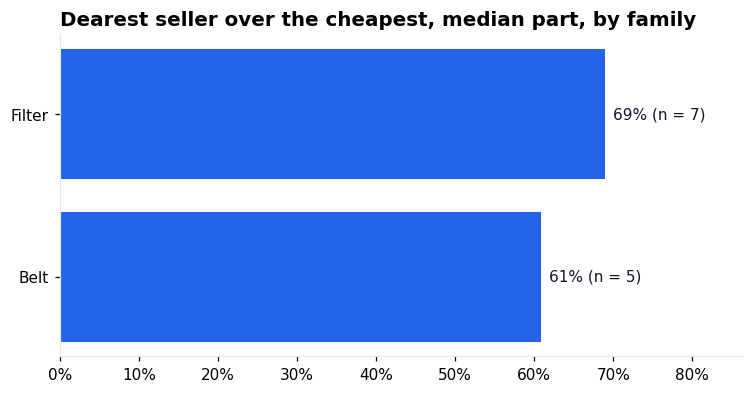

In [9]:
spread = (market.groupby(["part_no", "family", "match_grade"]).their_price.agg(["min", "max"])
          .assign(spread_pct=lambda d: 100 * (d["max"] / d["min"] - 1)).reset_index())
N["spread_median_pct"], N["spread_groups"] = spread.spread_pct.median(), len(spread)
for grade, g in spread.groupby("match_grade"):
    N[f"spread_median_pct_{grade}"], N[f"spread_groups_{grade}"] = g.spread_pct.median(), len(g)
fam = spread.groupby("family").spread_pct.agg(["median", "size"])
for family, row in fam.iterrows():
    N[f"spread_median_pct_{family.replace(' ', '_')}"] = row["median"] if row["size"] >= MIN_GROUPS else None
fam = fam[fam["size"] >= MIN_GROUPS].sort_values("median")
N["spread_top_family"], N["spread_top_family_pct"] = fam.index[-1], fam["median"].iat[-1]

# The 6PK2360 belt of the picture in the README: its single-piece group.
belt = market[market.name.str.contains("6PK2360")]
N["spread_6pk2360_pct"] = None
for part_no, g in belt.groupby("part_no"):
    print(f"{part_no} {g['name'].iat[0]} (our price {g.our_price.iat[0]} EGP): " +
          ", ".join(f"{r.seller} {r.their_price:,.2f}" for r in g.sort_values("their_price").itertuples()))
    N["spread_6pk2360_pct"] = 100 * (g.their_price.max() / g.their_price.min() - 1)
shown_out = for_car(gap[gap.in_stock.eq(False) & gap.name.str.contains("6PK2360")], "part_car_key")
for r in shown_out.itertuples():
    print(f"  shown out of stock, left out: {NAME[r.seller_id]} {float(r.their_price):,.2f}")

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.barh([f.capitalize() for f in fam.index], fam["median"], color=ACCENT)
for y, (value, n) in enumerate(zip(fam["median"], fam["size"])):
    ax.text(value + 1, y, f"{value:.0f}% (n = {n})", va="center", color=INK)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
ax.set_xlim(0, fam["median"].max() * 1.25)
ax.set_title("Dearest seller over the cheapest, median part, by family")
fig.savefig(ROOT / "docs" / "spread-by-family.png")
print(f"In the median part the dearest seller is {N['spread_median_pct']:.1f}% above the cheapest "
      f"(n = {N['spread_groups']} parts); most in {N['spread_top_family']}s ({N['spread_top_family_pct']:.1f}%).")

## Insight 2. Price leadership

How often each seller is the cheapest in the measured parts it sells, and its price index: its
comparable price over the group's median, the median over its parts (below 1 = below the market's
middle). Sellers in fewer than 5 measured parts are left out of the chart.

Tawfiqia is the cheapest in 83.3% of the 6 measured parts it sells (median price index 0.62).


,seller_id,seller,parts,cheapest,price_index,share
6,tawfiqia,Tawfiqia,6,5,0.623,0.833
1,autospare,AutoSpare,16,10,0.766,0.625
3,getradingeg,GE Trading,2,1,0.664,0.500
7,yourparts,YourParts,3,1,1.070,0.333
2,egycarparts,Egy Car Parts,7,1,1.000,0.143
0,amazon,Amazon Egypt,5,0,1.000,0.000
4,jumia,Jumia Egypt,1,0,1.000,0.000
5,nautoexpress,N Auto Express,3,0,0.958,0.000
8,zaitandfilters,Zait and Filters,12,0,0.908,0.000


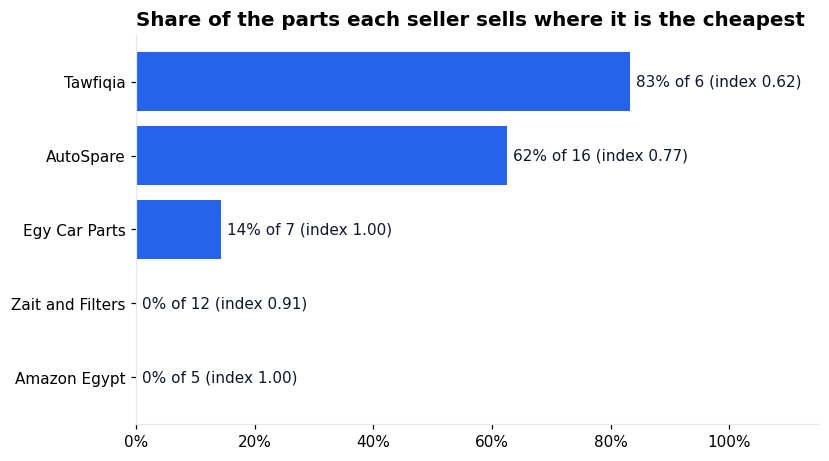

In [10]:
lead = (market.assign(cheapest=market.their_price == market.groupby("part_no").their_price.transform("min"))
        .groupby(["seller_id", "seller"]).agg(parts=("part_no", "size"), cheapest=("cheapest", "sum"),
                                              price_index=("price_index", "median")).reset_index())
lead["share"] = lead.cheapest / lead.parts
for r in lead.itertuples():
    N[f"compete_parts_{r.seller_id}"] = int(r.parts)
    N[f"lead_share_{r.seller_id}_pct"] = 100 * r.share
    N[f"price_index_{r.seller_id}"] = r.price_index
shown = lead[lead.parts >= MIN_GROUPS].sort_values("share")
top = shown.iloc[-1]
N["leader"], N["leader_share_pct"], N["leader_parts"] = top.seller, 100 * top.share, int(top.parts)
N["leader_price_index"] = top.price_index
N["leader_below_median_pct"] = 100 * (1 - top.price_index)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(shown.seller, shown.share, color=ACCENT)
for y, (share, n, index) in enumerate(zip(shown.share, shown.parts, shown.price_index)):
    ax.text(share + 0.01, y, f"{share:.0%} of {n} (index {index:.2f})", va="center", color=INK)
ax.set_xlim(0, 1.15)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Share of the parts each seller sells where it is the cheapest")
fig.savefig(ROOT / "docs" / "price-leadership.png")
print(f"{N['leader']} is the cheapest in {N['leader_share_pct']:.1f}% of the {N['leader_parts']} measured parts it sells "
      f"(median price index {N['leader_price_index']:.2f}).")
lead.sort_values("share", ascending=False).round(3)

## Insight 3. Discounts

The share of each seller's offers shown with a struck-out previous price. How deep a discount is cannot
be measured: the struck-out price is not kept in gold or silver, only whether one was shown. Whether a
discounted price sits below the market: the price index of discounted against undiscounted offers in
the measured parts. A seller that shows a struck-out price on every offer says nothing about a
discount, so it is left out of that comparison.

0.7% of 405 offers show a struck-out price; no seller shows one on every offer (grey, left out below).
Not compared: 0 discounted and 166 undiscounted offers in measured parts


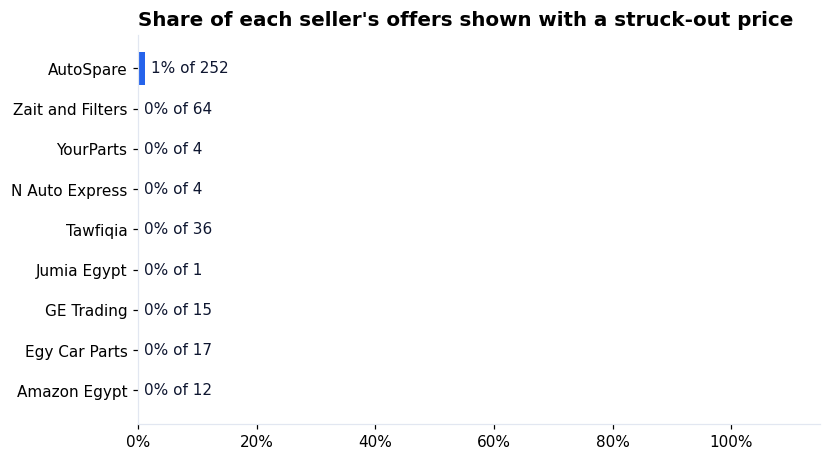

In [11]:
disc = offers.groupby("seller_id").is_discounted.agg(["mean", "size"])
for seller_id, row in disc.iterrows():
    N[f"discount_share_{seller_id}_pct"] = 100 * row["mean"]
N["discount_share_pct"] = 100 * offers.is_discounted.mean()
N["discount_depth_median_pct"] = None  # the struck-out price is not kept
always = sorted(disc.index[disc["mean"] == 1])
N["discount_always_sellers"] = len(always)

priced = usable[usable.part_no.isin(measured.index) & ~usable.seller_id.isin(always)].join(measured["median"], on="part_no")
priced = priced.assign(price_index=priced.price / priced["median"])
for flag, name in ((True, "discounted"), (False, "full_price")):
    g = priced[priced.is_discounted == flag]
    N[f"{name}_index_median"], N[f"{name}_offers"] = (g.price_index.median() if len(g) else None), len(g)
    N[f"{name}_below_median_pct"] = pct(int((g.price_index < 1).sum()), len(g))

shown = disc[disc["size"] > 0].sort_values("mean")
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh([NAME[s] for s in shown.index], shown["mean"], color=[GREY if s in always else ACCENT for s in shown.index])
for y, (share, n) in enumerate(zip(shown["mean"], shown["size"])):
    ax.text(share + 0.01, y, f"{share:.0%} of {n:,}", va="center", color=INK)
ax.set_xlim(0, 1.15)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.set_title("Share of each seller's offers shown with a struck-out price")
fig.savefig(ROOT / "docs" / "discounts-by-seller.png")
print(f"{N['discount_share_pct']:.1f}% of {len(offers):,} offers show a struck-out price; "
      f"{', '.join(NAME[s] for s in always) or 'no seller'} shows one on every offer (grey, left out below).")
if N["discounted_offers"] and N["full_price_offers"]:
    print(f"Discounted offers: median price index {N['discounted_index_median']:.2f}, {N['discounted_below_median_pct']:.1f}% below "
          f"the group median (n = {N['discounted_offers']}); undiscounted: {N['full_price_index_median']:.2f}, "
          f"{N['full_price_below_median_pct']:.1f}% below (n = {N['full_price_offers']}).")
else:
    print(f"Not compared: {N['discounted_offers']} discounted and {N['full_price_offers']} undiscounted offers in measured parts")

## Insight 4. Brand premium

Genuine against aftermarket for the same part type and car: the `type_model` groups. The brand of an
offer is not in gold, so it is read from `silver.offer.brand`. A brand is genuine when it is the car
maker's own (the list below, printed); every other named brand is aftermarket; no brand, "Generic"
and a seller's own name are left out. Per measured group with both kinds, the premium is the median
genuine price over the median aftermarket price, minus one.

Genuine brands: CHERY, DAEWOO, FAW VOLKSWAGEN, GENUINE, GENUINE PARTS, GM, KIA, MITSUBISHI, MITSUBISHI MOTORS, MOBIS, MOBIS PL2, NISSAN, NISSAN GROUP, OEM, PSA GROUP, RENAULT GROUP, SAIC MOTOR, SCL GENUINE PARTS, VW GROUP, اصلى, اصلي
114 branded comparable offers in measured type_model groups; 5 groups have both kinds.
The genuine brand costs a median -6.1% more than the aftermarket one (n = 5 groups; genuine dearer in 40.0% of them).


,median premium %,groups
family,,
filter,-6.103286,5




In [12]:
GENUINE = {"OEM", "GENUINE", "GENUINE PARTS", "SCL GENUINE PARTS", "اصلي", "اصلى", "MOBIS", "MOBIS PL2", "GM",
           "DAEWOO", "CHERY", "KIA", "NISSAN", "NISSAN GROUP", "RENAULT GROUP", "PSA GROUP", "VW GROUP",
           "FAW VOLKSWAGEN", "MITSUBISHI", "MITSUBISHI MOTORS", "SAIC MOTOR"}
UNKNOWN = {"GENERIC", *(name.upper() for name in NAME.values())}
brands = query("SELECT seller_id, listing_key, brand FROM silver.offer WHERE brand IS NOT NULL")
brands["brand"] = brands.brand.str.upper().str.split().str.join(" ")
branded = (usable[usable.part_no.isin(measured.index) & (usable.match_grade == "type_model")]
           .merge(brands, on=["seller_id", "listing_key"]))
branded = branded[~branded.brand.isin(UNKNOWN)].assign(genuine=lambda d: d.brand.isin(GENUINE))
print("Genuine brands:", ", ".join(sorted(GENUINE)))
both = branded.groupby(["part_no", "family", "genuine"]).price.median().unstack("genuine").reindex(columns=[True, False]).dropna()
both["premium_pct"] = 100 * (both[True] / both[False] - 1)
both = both.reset_index()
N["brand_offers"] = len(branded)
N["brand_groups"] = len(both)
N["brand_premium_median_pct"] = both.premium_pct.median() if len(both) >= MIN_GROUPS else None
N["brand_genuine_dearer_pct"] = pct(int((both.premium_pct > 0).sum()), len(both))
fam = both.groupby("family").premium_pct.agg(["median", "size"])
for family, row in fam.iterrows():
    N[f"brand_premium_median_pct_{family.replace(' ', '_')}"] = row["median"] if row["size"] >= MIN_GROUPS else None
fam = fam[fam["size"] >= MIN_GROUPS].sort_values("median")

if len(fam):  # a chart needs one family with 5 groups or more
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.barh([f.capitalize() for f in fam.index], fam["median"], color=ACCENT)
    for y, (value, n) in enumerate(zip(fam["median"], fam["size"])):
        ax.text(max(value, 0) + 1, y, f"{value:+.0f}% (n = {n})", va="center", color=INK)
    ax.axvline(0, color=GREY, linewidth=1)
    ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
    ax.set_xlim(min(0, fam["median"].min() * 1.25), fam["median"].max() * 1.3)
    ax.set_title("Genuine brand over aftermarket, same part type and car, median group")
    fig.savefig(ROOT / "docs" / "brand-premium.png")
print(f"{len(branded):,} branded comparable offers in measured type_model groups; {len(both)} groups have both kinds.")
if N["brand_premium_median_pct"] is not None:
    print(f"The genuine brand costs a median {N['brand_premium_median_pct']:.1f}% more than the aftermarket one "
          f"(n = {len(both)} groups; genuine dearer in {N['brand_genuine_dearer_pct']:.1f}% of them).")
fam.rename(columns={"median": "median premium %", "size": "groups"})

## Insight 5. Coverage: which cars, and what is in stock

Offers by the car model their title names (`car_key` without its years), and the share of each
seller's offers in stock where the site says.

GE Trading only marks a product out of stock: 12 of its 15 offers; no in-stock share
405 of 405 offers (100.0%) name a car: 1 models of 1 makes; the most listed is Chevrolet Optra (405 offers).
Where the site says, 91.0% of 288 offers are in stock:


AutoSpare    96.0
Tawfiqia     55.6
Name: in stock %, dtype: float64

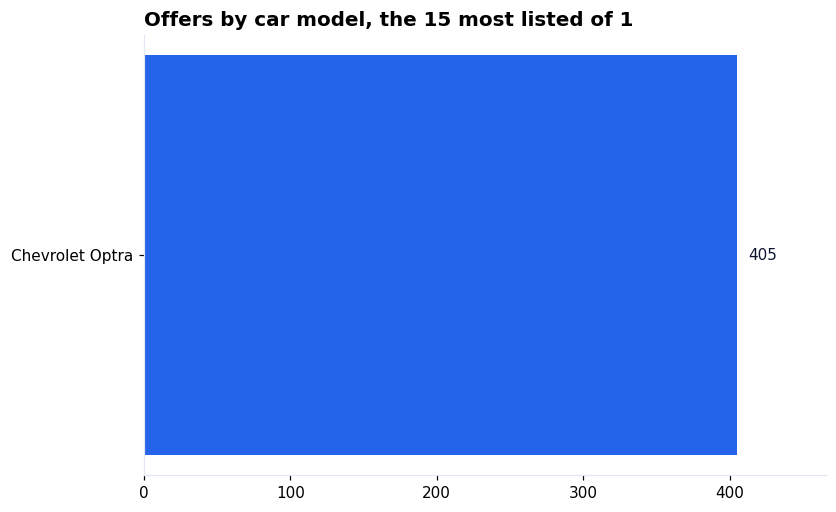

In [13]:
cars = offers[offers.car_key.notna()].assign(model=lambda d: d.car_key.str.replace(r"-\d{4}-\d{4}$", "", regex=True))
N["offers_with_car"], N["offers_with_car_pct"] = len(cars), pct(len(cars), len(offers))
N["car_models"], N["car_makes"] = cars.model.nunique(), cars.model.str.split("-").str[0].nunique()
by_model = cars.groupby("model").size().sort_values()
N["top_model"], N["top_model_offers"] = by_model.index[-1].replace("-", " ").title(), int(by_model.iat[-1])
# A site that only ever marks a product out of stock (GE Trading) gives no in-stock share: left out.
says = offers.groupby("seller_id").in_stock.agg(lambda s: s.eq(True).any() and s.eq(False).any())
said = offers[offers.seller_id.isin(says.index[says]) & offers.in_stock.notna()]
for seller_id in sellers.seller_id:
    mine = said[said.seller_id == seller_id]
    N[f"in_stock_{seller_id}_pct"] = pct(int(mine.in_stock.astype(bool).sum()), len(mine))
for seller_id in says.index[~says]:
    out = int(offers[offers.seller_id == seller_id].in_stock.eq(False).sum())
    if out:
        print(f"{NAME[seller_id]} only marks a product out of stock: {out:,} of its "
              f"{int((offers.seller_id == seller_id).sum()):,} offers; no in-stock share")
N["in_stock_pct"], N["stock_stated_offers"] = pct(int(said.in_stock.astype(bool).sum()), len(said)), len(said)

top15 = by_model.iloc[-15:]
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.barh([m.replace("-", " ").title() for m in top15.index], top15, color=ACCENT)
for y, n in enumerate(top15):
    ax.text(n + 8, y, f"{n:,}", va="center", color=INK)
ax.set_xlim(0, top15.max() * 1.15)
ax.set_title(f"Offers by car model, the 15 most listed of {N['car_models']}")
fig.savefig(ROOT / "docs" / "offers-by-car.png")
print(f"{N['offers_with_car']:,} of {len(offers):,} offers ({N['offers_with_car_pct']:.1f}%) name a car: {N['car_models']} models of "
      f"{N['car_makes']} makes; the most listed is {N['top_model']} ({N['top_model_offers']:,} offers).")
print(f"Where the site says, {N['in_stock_pct']:.1f}% of {len(said):,} offers are in stock:")
pd.Series({NAME[s]: N[f"in_stock_{s}_pct"] for s in sellers.seller_id}).dropna().round(1).rename("in stock %")

## Insight 6. The retailer's view

The parts where a seller is at least 5% below our price, comparable and not shown out of stock (the
`gold.undercut` view), by match grade and family; how far below, at the cheapest such seller; and the
10 key parts to reprice first: the largest gap among key parts.

Share of parts with a seller at least 5% below, by family: belt 100.0% of 5, spark plug 100.0% of 2, filter 87.5% of 8, brake pad 66.7% of 6
18 of 21 parts (85.7%) have a seller at least 5% below our price: 2 of 3 by part number, 16 of 18 by part type and car; 4 of 4 key parts.
At the cheapest such seller, a median 29.4% below ours (n = 18 parts).
Reprice first: gaps from 26.9% to 63.8%; 4 of the 10 are part type and car groups, where brands mix, and a gap near 66.7% is a price near a third of the group's median, the edge of the comparable rule: check those listings first.


,part_no,name,match_grade,seller_id,their_price,our_price,gap_pct
425,EG-4E5AFEB5,Air filter for Chevrolet Optra,type_model,tawfiqia,95.00,262.50,63.8
1183,EG-D0F16567,Brake pad front for Chevrolet Optra,type_model,tawfiqia,380.00,730.00,47.9
1374,EG-EF2E771D,Cabin filter for Chevrolet Optra,type_model,autospare,150.00,264.50,43.3
1064,EG-BB7969FE,Spark plug set for Chevrolet Optra,type_model,yourparts,450.00,616.00,26.9


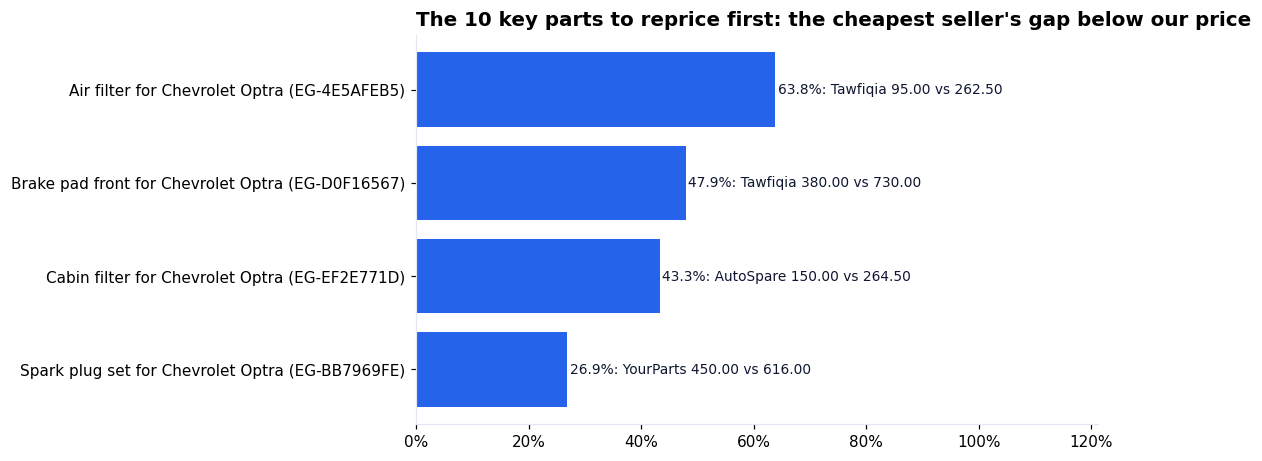

In [14]:
under = for_car(query("SELECT u.*, p.car_key AS part_car_key FROM gold.undercut u JOIN gold.dim_part p USING (part_no)"),
                "part_car_key")
under["gap_pct"] = under.gap_pct.astype(float)
deepest = under.sort_values("gap_pct", ascending=False).drop_duplicates("part_no")
N["parts_below"], N["parts_below_pct"] = len(deepest), pct(len(deepest), N["parts"])
N["key_parts_below"] = int(deepest.is_key.sum())
N["key_parts_below_pct"] = pct(N["key_parts_below"], N["key_parts"])
for grade in ("part_number", "type_model"):
    n = int((deepest.match_grade == grade).sum())
    N[f"parts_below_{grade}"], N[f"parts_below_{grade}_pct"] = n, pct(n, N[f"parts_{grade}"])
N["undercut_gap_median_pct"] = deepest.gap_pct.median()
for grade, g in deepest.groupby("match_grade"):
    N[f"undercut_gap_median_pct_{grade}"] = g.gap_pct.median()

fam = (parts.assign(below=parts.part_no.isin(deepest.part_no)).groupby("family").below.agg(["mean", "size"]))
for family, row in fam.iterrows():
    N[f"parts_below_{family.replace(' ', '_')}_pct"] = 100 * row["mean"] if row["size"] >= MIN_GROUPS else None
print("Share of parts with a seller at least 5% below, by family:",
      ", ".join(f"{f} {100 * r['mean']:.1f}% of {int(r['size'])}" for f, r in fam.sort_values("mean", ascending=False).iterrows()))

first = deepest[deepest.is_key].head(10)
N["reprice_first"] = first.part_no.tolist()
N["reprice_first_gap_min_pct"], N["reprice_first_gap_max_pct"] = first.gap_pct.min(), first.gap_pct.max()
N["reprice_first_type_model"] = int((first.match_grade == "type_model").sum())

fig, ax = plt.subplots(figsize=(8, 4.6))
labels = [f"{r.name} ({r.part_no})" for r in first.itertuples()][::-1]
ax.barh(labels, first.gap_pct[::-1], color=ACCENT)
for y, r in enumerate(list(first.itertuples())[::-1]):
    ax.text(r.gap_pct + 0.5, y, f"{r.gap_pct:.1f}%: {NAME[r.seller_id]} {float(r.their_price):,.2f} vs {float(r.our_price):,.2f}",
            va="center", color=INK, fontsize=9)
ax.set_xlim(0, first.gap_pct.max() * 1.9)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0f}%")
ax.set_title("The 10 key parts to reprice first: the cheapest seller's gap below our price")
fig.savefig(ROOT / "docs" / "reprice-first.png")
print(f"{N['parts_below']} of {N['parts']} parts ({N['parts_below_pct']:.1f}%) have a seller at least 5% below our price: "
      f"{N['parts_below_part_number']} of {N['parts_part_number']} by part number, {N['parts_below_type_model']} of "
      f"{N['parts_type_model']} by part type and car; {N['key_parts_below']} of {N['key_parts']} key parts.")
print(f"At the cheapest such seller, a median {N['undercut_gap_median_pct']:.1f}% below ours (n = {len(deepest)} parts).")
print(f"Reprice first: gaps from {N['reprice_first_gap_min_pct']:.1f}% to {N['reprice_first_gap_max_pct']:.1f}%; "
      f"{N['reprice_first_type_model']} of the 10 are part type and car groups, where brands mix, and a gap near 66.7% "
      "is a price near a third of the group's median, the edge of the comparable rule: check those listings first.")
first[["part_no", "name", "match_grade", "seller_id", "their_price", "our_price", "gap_pct"]]

## Insight 7. Week over week

Price changes need a second run week: `gold.price_change` compares each offer with its previous week.

In [15]:
weeks = query("SELECT count(DISTINCT run_week) AS n FROM gold.fact_price_observation JOIN gold.dim_date USING (date_key)").n.iat[0]
N["run_weeks"] = int(weeks)
if weeks < 2:
    N["price_changes"] = N["price_cuts"] = N["price_rises"] = None
    print(f"Needs two run weeks: {weeks} loaded so far")
else:
    changes = for_car(query("SELECT c.*, p.car_key AS part_car_key FROM gold.price_change c JOIN gold.dim_part p USING (part_no) "
                            "WHERE c.run_week = %s", RUN_WEEK), "part_car_key")
    N["price_changes"] = len(changes)
    N["price_cuts"] = int((changes.change_egp < 0).sum())
    N["price_rises"] = int((changes.change_egp > 0).sum())
    print(f"{N['price_changes']} price changes in run week {RUN_WEEK}: {N['price_cuts']} cuts, {N['price_rises']} rises")

Needs two run weeks: 1 loaded so far


## 8. How long the fetch takes

Measured from the kept pages, so a fresh clone gets the same numbers: each page's line in
`data/raw/<seller_id>/<run_week>/index.jsonl` carries the time it was fetched (`fetched_at`). A
seller's fetch span is its last `fetched_at` less its first, over the pages the weekly run fetched (a
line with `via` `browser` came from `scripts/fetch_with_browser.py` and is left out). The sellers are
fetched in parallel, one task each, so a live weekly run is bound by its slowest seller:
`fetch_longest_minutes` is the slowest seller's fetch span.

In run week 2026-10-05, Auto Spare, Garage ILLA, N Auto Express, Pringi and Spare Zone were fetched in
an earlier run on the same day (from 00:37 UTC), the other eight sellers from 02:24 UTC. So the span is
per seller, not a wall-clock total from the first page fetched to the last.

In [16]:
spans = []
for seller_id in sellers.seller_id:
    with open(ROOT / "data" / "raw" / seller_id / str(RUN_WEEK) / "index.jsonl", encoding="utf-8") as f:
        fetched = [pd.Timestamp(line["fetched_at"]) for line in map(json.loads, f)
                   if line.get("via", "requests") != "browser"]
    if not fetched:
        raise ValueError(f"{seller_id}: no page fetched by the weekly run in {RUN_WEEK}")
    spans.append((NAME[seller_id], len(fetched), min(fetched), max(fetched),
                  (max(fetched) - min(fetched)).total_seconds() / 60))
spans = pd.DataFrame(spans, columns=["seller", "pages", "first fetched", "last fetched", "minutes"])
spans = spans.sort_values("minutes", ascending=False, ignore_index=True)
N["fetch_longest_minutes"] = round(float(spans.minutes.iat[0]))
print(f"The slowest seller, {spans.seller.iat[0]}, took {spans.minutes.iat[0]:.2f} minutes from its first page to its last "
      f"({spans.pages.iat[0]:,} pages); a live weekly run is bound by it.")
spans.round({"minutes": 2})

The slowest seller, Zait and Filters, took 179.74 minutes from its first page to its last (3,490 pages); a live weekly run is bound by it.


,seller,pages,first fetched,last fetched,minutes
0,Zait and Filters,3490,2026-10-05 02:24:50.187659+00:00,2026-10-05 05:24:34.431088+00:00,179.74
1,AutoSpare,669,2026-10-05 00:37:43.770899+00:00,2026-10-05 01:30:41.365703+00:00,52.96
2,Tawfiqia,246,2026-10-05 02:33:20.491924+00:00,2026-10-05 02:47:04.185713+00:00,13.73
3,GE Trading,135,2026-10-05 02:28:09.046608+00:00,2026-10-05 02:35:29.923927+00:00,7.35
4,Jumia Egypt,42,2026-10-05 02:28:43.515654+00:00,2026-10-05 02:33:08.256102+00:00,4.41
5,Amazon Egypt,52,2026-10-05 02:24:42.278217+00:00,2026-10-05 02:28:34.685088+00:00,3.87
6,Pringi,24,2026-10-05 00:37:46.197313+00:00,2026-10-05 00:39:45.758817+00:00,1.99
7,Egy Car Parts,37,2026-10-05 02:24:58.577524+00:00,2026-10-05 02:26:47.948239+00:00,1.82
8,N Auto Express,22,2026-10-05 00:37:43.616879+00:00,2026-10-05 00:38:55.509128+00:00,1.20
9,YourParts,14,2026-10-05 02:35:37.933245+00:00,2026-10-05 02:36:17.345522+00:00,0.66


## 9. The writer

`analysis/numbers.json` gets every number above. Then the text between each `<!--n:KEY-->` and
`<!--/n-->` in the README and in `docs/*.svg` is rewritten from it: whole numbers with thousands
separators, others to one decimal. A marker whose key is not in `numbers.json` stops the notebook.

In [17]:
def plain(value):
    return value.item() if hasattr(value, "item") else value


numbers = {key: plain(value) for key, value in N.items()}
(ROOT / "analysis" / "numbers.json").write_text(json.dumps(numbers, indent=2, sort_keys=True, ensure_ascii=False) + "\n",
                                                 encoding="utf-8")


def shown(value):
    if value is None:
        return "n/a"
    return f"{value:,}" if isinstance(value, int) else f"{value:,.1f}" if isinstance(value, float) else str(value)


MARKER = re.compile(r"<!--n:([a-z0-9_]+)-->(.*?)<!--/n-->", re.S)
used, missing = set(), []
for path in [ROOT / "README.md", *sorted((ROOT / "docs").glob("*.svg"))]:
    with open(path, encoding="utf-8", newline="") as f:
        text = f.read()

    def fill(match):
        key = match.group(1)
        if key not in numbers:
            missing.append(f"{path.name}: {key}")
            return match.group(0)
        used.add(key)
        return f"<!--n:{key}-->{shown(numbers[key])}<!--/n-->"

    text = MARKER.sub(fill, text)
    if missing:
        raise KeyError(f"markers with no number in numbers.json: {missing}")
    with open(path, "w", encoding="utf-8", newline="") as f:
        f.write(text)
print(f"{len(numbers)} numbers written; {len(used)} used in the README and docs/*.svg")
print("Not used:", ", ".join(sorted(set(numbers) - used)))

202 numbers written; 54 used in the README and docs/*.svg
Not used: brand_genuine_dearer_pct, brand_groups, brand_offers, brand_premium_median_pct, brand_premium_median_pct_filter, car_key, cheapest_parts_amazon, cheapest_parts_autospare, cheapest_parts_egycarparts, cheapest_parts_fitandfix, cheapest_parts_garageilla, cheapest_parts_getradingeg, cheapest_parts_jumia, cheapest_parts_nautoexpress, cheapest_parts_pringi, cheapest_parts_sparezone, cheapest_parts_tawfiqia, cheapest_parts_yourparts, cheapest_parts_zaitandfilters, cheapest_ties, compete_parts_amazon, compete_parts_autospare, compete_parts_egycarparts, compete_parts_getradingeg, compete_parts_jumia, compete_parts_nautoexpress, compete_parts_tawfiqia, compete_parts_yourparts, compete_parts_zaitandfilters, coverage_autospare_pct, coverage_egycarparts_pct, coverage_fitandfix_pct, coverage_jumia_pct, coverage_tawfiqia_pct, discount_always_sellers, discount_depth_median_pct, discount_share_amazon_pct, discount_share_autospare_pct, 